# Baseline heurístico

Usando _simple weighted heuristic_ (SWH) usando _weak explainable phishing indicators_ (WEPI) asignando puntos a la presencia de marcadores lingüísticos y estilométricos particulares.

In [1]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)
import pandas as pd

Se carga el dataset.

In [2]:
y_test = pd.read_csv('datasets/y_test.csv')['label']
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

Se implementa ponderación por feature generado.

In [3]:
def heuristic_baseline(email_features):
    score = 0
    if email_features['imperative_verbs_count'] > 0: score += 2
    if email_features['pronoun_density'] > 0: score += 2
    if email_features['urgency_markers_count'] > 0: score += 1
    if email_features['domain_dot_high'] == 1: score += 2
    if email_features['has_suspicious_tags'] == 1: score += 2
    if email_features['has_link'] == 1: score += 1
    
    return 1 if score >= 3 else 0

Se aplica.

In [4]:
y_baseline = X_extra_test.apply(heuristic_baseline, axis=1)

### Métricas

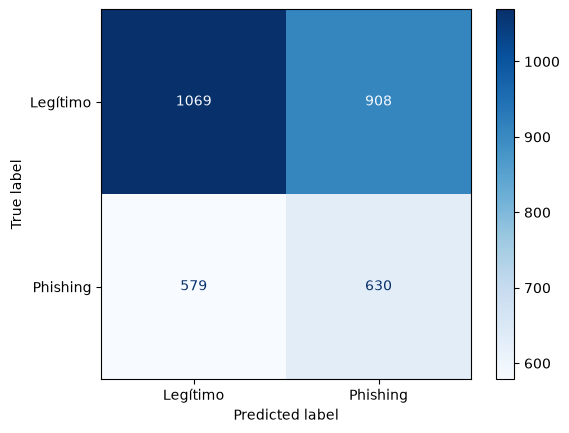

In [5]:
ConfusionMatrixDisplay.from_predictions(y_test, y_baseline, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [6]:
cm_baseline = confusion_matrix(y_test, y_baseline)
P = cm_baseline[1, :].sum()
N = cm_baseline[0, :].sum()
TP = cm_baseline[1, 1]
TN = cm_baseline[0, 0]

TPR_baseline = TP / P
TNR_baseline = TN / N
balanced_accuracy_baseline = (TPR_baseline + TNR_baseline) / 2

precision_baseline = precision_score(y_test, y_baseline, zero_division=0)
recall_baseline = recall_score(y_test, y_baseline, zero_division=0)
f1_baseline = f1_score(y_test, y_baseline, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_baseline:.4f}")
print(f"Precisión:               {precision_baseline:.4f}")
print(f"Sensibilidad (Recall):   {TPR_baseline:.4f}")
print(f"F1-score:                {f1_baseline:.4f}")
print(f"Especificidad:           {TNR_baseline:.4f}")
print(f"Recuperación (Recall):   {recall_baseline:.4f}")

Exactitud balanceada:    0.5309
Precisión:               0.4096
Sensibilidad (Recall):   0.5211
F1-score:                0.4587
Especificidad:           0.5407
Recuperación (Recall):   0.5211


Es un desastre, es poco mejor que adivinar. Esto lo menciona la bibliografía, ya que para alcanzar una buena performance (96% o más) hace falta incorporar componentes estilométricas.